In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

In [3]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/cloudy_grids/non_eqm_models/'

Read in temperatures

In [4]:
T_grid = np.loadtxt(rootdir+'CI/TDC_isochoric/log_metals=0/T0=1e8K/TDC_isochoric_frac.tim')[:,4]

Read emission and two-photon continuum

In [5]:
with open(rootdir+'CI/TDC_isochoric/log_metals=0/T0=1e8K/TDC_isochoric_frac.conem') as file:
    L_em = [line.rstrip() for line in file]
    
with open(rootdir+'CI/TDC_isochoric/log_metals=0/T0=1e8K/TDC_isochoric_frac.contp') as file:
    L_tp = [line.rstrip() for line in file]

In [13]:
wav_grid = []
nu_f_nu_total_grid = []
nu_f_nu_tp_grid = []

for i in range(1, len(L_em)):
    if '###########################' not in L_em[i]:
        L_em_split = L_em[i].split('\t')
        wav_grid.append(float(L_em_split[0]))
        nu_f_nu_total_grid.append(float(L_em_split[3]))
        
for i in range(1, len(L_tp)):
    if '###########################' not in L_tp[i]:
        L_tp_split = L_tp[i].split('\t')
        nu_f_nu_tp_grid.append(float(L_tp_split[2]))

Reshape

In [14]:
n_steps_T = len(T_grid)
n_steps_wav = (len(L_em[1:])-n_steps_T)//n_steps_T

In [15]:
wav_grid = np.array(wav_grid)
wav_grid = wav_grid.reshape((n_steps_T,n_steps_wav))

#nu_grid = np.array(nu_grid)
#nu_grid = nu_grid.reshape((n_steps_T,n_steps_nu))

nu_f_nu_total_grid = np.array(nu_f_nu_total_grid)
nu_f_nu_total_grid = nu_f_nu_total_grid.reshape((n_steps_T,n_steps_wav))
#f_nu_total_grid = nu_f_nu_total_grid/nu_grid

nu_f_nu_tp_grid = np.array(nu_f_nu_tp_grid)
nu_f_nu_tp_grid = nu_f_nu_tp_grid.reshape((n_steps_T,n_steps_wav))
#f_nu_tp_grid = nu_f_nu_tp_grid/nu_grid

Convert to standard units

In [16]:
#wav_grid = 1e10*3e8/nu_grid # In Å
# Since nu*F_nu = lam*F_lam
f_lam_total_grid = nu_f_nu_total_grid/wav_grid #(nu_grid**2/3e8)*f_nu_total_grid*1e7*1e-4*1e-10
f_lam_tp_grid = nu_f_nu_tp_grid/wav_grid #(nu_grid**2/3e8)*f_nu_tp_grid*1e7*1e-4*1e-10

Make a plot to test

In [17]:
logT_grid = np.log10(T_grid)

/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_5282/627415355.py:3: RuntimeWarning: divide by zero encountered in log10
  ax.step(wav_grid[0,:], np.log10(f_lam_total_grid[0,:]), where='mid', color='red',
/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_5282/627415355.py:5: RuntimeWarning: divide by zero encountered in log10
  ax.step(wav_grid[100,:], np.log10(f_lam_total_grid[100,:]), where='mid', color='green',
/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_5282/627415355.py:7: RuntimeWarning: divide by zero encountered in log10
  ax.step(wav_grid[200,:], np.log10(f_lam_total_grid[200,:]), where='mid', color='blue',


Text(0.5, 1.0, 'Ly$\\alpha$ evolution for time-dependent cooling')

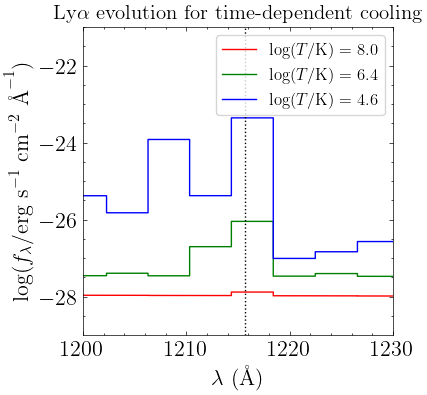

In [18]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.step(wav_grid[0,:], np.log10(f_lam_total_grid[0,:]), where='mid', color='red', 
        label=r'$\log(T/\mathrm{K})=$'+' {}'.format(np.round(logT_grid[0],1)))
ax.step(wav_grid[100,:], np.log10(f_lam_total_grid[100,:]), where='mid', color='green', 
        label=r'$\log(T/\mathrm{K})=$'+' {}'.format(np.round(logT_grid[100],1)))
ax.step(wav_grid[200,:], np.log10(f_lam_total_grid[200,:]), where='mid', color='blue', 
        label=r'$\log(T/\mathrm{K})=$'+' {}'.format(np.round(logT_grid[200],1)))

ax.legend()

ax.axvline(1215.67, linestyle=':')
ax.set_xlim(1200,1230)
ax.set_ylim(-25.1, -24.7)
ax.set_ylim(-29, -21)
ax.set_xlabel(r'$\lambda$ (Å)')
ax.set_ylabel(r'$\log(f_\lambda/\mathrm{erg \ \mathrm{s}^{-1} \ \mathrm{cm}^{-2} \ \mathrm{Å}^{-1}})$')

ax.set_title(r'Ly$\alpha$ evolution for time-dependent cooling', fontsize=15)
#ax.set_ylim(-1e-30, 1e30)
#ax.axvline(1215)

/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_5282/1610093631.py:3: RuntimeWarning: divide by zero encountered in log10
  ax.step(np.log10(wav_grid[0,:]), np.log10(f_lam_tp_grid[0,:]), where='mid', color='red',
/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_5282/1610093631.py:5: RuntimeWarning: divide by zero encountered in log10
  ax.step(np.log10(wav_grid[100,:]), np.log10(f_lam_tp_grid[100,:]), where='mid', color='green',
/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_5282/1610093631.py:7: RuntimeWarning: divide by zero encountered in log10
  ax.step(np.log10(wav_grid[200,:]), np.log10(f_lam_tp_grid[200,:]), where='mid', color='blue',


Text(0.5, 1.0, '2-photon evolution for time-dependent cooling')

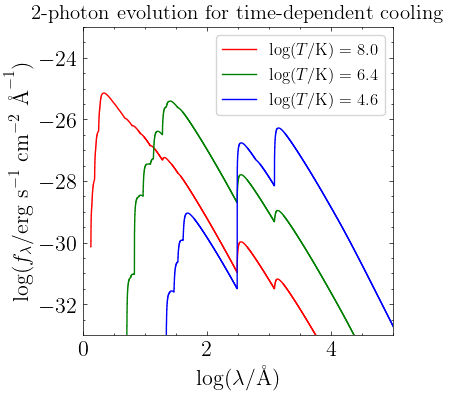

In [19]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.step(np.log10(wav_grid[0,:]), np.log10(f_lam_tp_grid[0,:]), where='mid', color='red', 
        label=r'$\log(T/\mathrm{K})=$'+' {}'.format(np.round(logT_grid[0],1)))
ax.step(np.log10(wav_grid[100,:]), np.log10(f_lam_tp_grid[100,:]), where='mid', color='green', 
        label=r'$\log(T/\mathrm{K})=$'+' {}'.format(np.round(logT_grid[100],1)))
ax.step(np.log10(wav_grid[200,:]), np.log10(f_lam_tp_grid[200,:]), where='mid', color='blue', 
        label=r'$\log(T/\mathrm{K})=$'+' {}'.format(np.round(logT_grid[200],1)))

ax.set_xlabel(r'$\log(\lambda/\mathrm{Å})$')
ax.set_ylabel(r'$\log(f_\lambda/\mathrm{erg \ \mathrm{s}^{-1} \ \mathrm{cm}^{-2} \ \mathrm{Å}^{-1}})$')

ax.legend()

ax.set_ylim(-33, -23)
ax.set_xlim(0,5)

ax.set_title(r'2-photon evolution for time-dependent cooling', fontsize=15)
#ax.set_xlim(900,1400)
#ax.set_ylim(-25.5, -24.6)
#ax.set_ylim(-1e-30, 1e30)
#ax.axvline(1215)